### PREPARATION

Base: Anton Achhammer, OTH Regensburg, [Source](https://github.com/doneachh/undergroundstorage/blob/main/workflow%2Fnotebooks%2Fgraphics.ipynb)

Adapted: Alexander Meisinger, OTH Regensburg



In [1]:
import yaml
import logging
import pypsa
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import numpy as np
from shapely.geometry import LineString
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import sys
import matplotlib as mpl
import matplotlib.lines as mlines
from matplotlib.patches import Wedge
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

In [2]:
logging.getLogger("pypsa.io").setLevel(logging.ERROR)
warnings.simplefilter(action='ignore', category=ResourceWarning)

country_name_1 = "Bulgaria" # Bulgaria, Romania
run_name_1 = "1h-sec"

country_name_2 = "Romania" # Bulgaria, Romania
run_name_2 = "1h-sec-2"

# Load the country_1 and country_2 networks
country_1 = pypsa.Network(f"/mnt/e/HySEE/{country_name_1}/pypsa-earth/results/postnetworks/elec_s_10_ec_lcopt_Co2L0.45-1h_1h_2030_0.07_AB_0export.nc")
country_2 = pypsa.Network(f"/mnt/e/HySEE/{country_name_2}/pypsa-earth/results/postnetworks/elec_s_10_ec_lcopt_Co2L0.45-1h_1h_2030_0.07_AB_0export.nc")

# Load geographic data for onshore regions and ports
regions_onshore_1 = gpd.read_file(f"/mnt/e/HySEE/{country_name_1}/pypsa-earth/resources/{run_name_1}/shapes/country_shapes.geojson")
regions_onshore_2 = gpd.read_file(f"/mnt/e/HySEE/{country_name_2}/pypsa-earth/resources/{run_name_2}/shapes/country_shapes.geojson")

ports_1 = pd.read_csv(f"/mnt/e/HySEE/{country_name_1}/pypsa-earth/resources/ports.csv")
ports_2 = pd.read_csv(f"/mnt/e/HySEE/{country_name_2}/pypsa-earth/resources/ports.csv")

# Create a GeoDataFrame for ports with point geometries
ports_1 = gpd.GeoDataFrame(
    ports_1,
    geometry=gpd.points_from_xy(ports_1["x"], ports_1["y"]),
    crs="EPSG:4326"  # Coordinates are in WGS84
)

ports_2 = gpd.GeoDataFrame(
    ports_2,
    geometry=gpd.points_from_xy(ports_2["x"], ports_2["y"]),
    crs="EPSG:4326"  # Coordinates are in WGS84
)

# Load GADM shapes and configuration file
gadm_shapes_1 = gpd.read_file(f"/mnt/e/HySEE/{country_name_1}/pypsa-earth/resources/{run_name_1}/shapes/gadm_shapes.geojson")
gadm_shapes_2 = gpd.read_file(f"/mnt/e/HySEE/{country_name_2}/pypsa-earth/resources/{run_name_2}/shapes/gadm_shapes.geojson")

country_1_gadm = gadm_shapes_1
country_2_gadm = gadm_shapes_2

config_1 = yaml.safe_load(open(f"/mnt/e/HySEE/HySEE-Preparation/config/{country_name_1}/config.yaml"))
config_2 = yaml.safe_load(open(f"/mnt/e/HySEE/HySEE-Preparation/config/{country_name_2}/config.yaml"))

# Define paths for network and renewable profiles
network_path_1 = f"/mnt/e/HySEE/{country_name_1}/pypsa-earth/networks/{run_name_1}/elec.nc"
solar_path_1 = f"/mnt/e/HySEE/{country_name_1}/pypsa-earth/resources/{run_name_1}/renewable_profiles/profile_solar.nc"
onwind_path_1 = f"/mnt/e/HySEE/{country_name_1}/pypsa-earth/resources/{run_name_1}/renewable_profiles/profile_onwind.nc"

network_path_2 = f"/mnt/e/HySEE/{country_name_2}/pypsa-earth/networks/{run_name_2}/elec.nc"
solar_path_2 = f"/mnt/e/HySEE/{country_name_2}/pypsa-earth/resources/{run_name_2}/renewable_profiles/profile_solar.nc"
onwind_path_2 = f"/mnt/e/HySEE/{country_name_2}/pypsa-earth/resources/{run_name_2}/renewable_profiles/profile_onwind.nc"


# Get the bounding box for the onshore regions
country_coordinates_1 = regions_onshore_1.total_bounds[[0, 2, 1, 3]]
country_coordinates_2 = regions_onshore_2.total_bounds[[0, 2, 1, 3]]

# Define colors for scenarios
tech_colors = config_1["plotting"]["tech_colors"]

# Normalize the carrier column/index to lowercase for easier matching
def get_color(carrier):
    # First, check for an exact match
    if carrier in tech_colors:
        return tech_colors[carrier]
    # Try matching with lowercase
    if carrier.lower() in tech_colors:
        return tech_colors[carrier.lower()]
    # Default color if no match is found
    return "lightgrey"

# Map colors to carriers in the country_1 network
country_1.carriers["color"] = country_1.carriers.index.map(get_color)
country_2.carriers["color"] = country_2.carriers.index.map(get_color)

if "H2 export" not in country_1.carriers.index:
    country_1.carriers.loc["H2 export", :] = np.nan

country_1.carriers.loc["H2 export", "color"] = "purple"
country_1.carriers.loc["H2 export", "nice_name"] = "H₂ export"

if "H2 export" not in country_2.carriers.index:
    country_2.carriers.loc["H2 export", :] = np.nan

country_2.carriers.loc["H2 export", "color"] = "purple"
country_2.carriers.loc["H2 export", "nice_name"] = "H₂ export"

warnings.simplefilter(action='default', category=ResourceWarning)

/home/alex-charly/anaconda3/envs/pypsa-earth-HySEE-BG/lib/python3.11/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


In [3]:
plt.rcParams.update({
    # Clean journal style
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Figure defaults
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Improve spacing
    "axes.titlepad": 10,
    "axes.labelpad": 6,
})

#### Regional H2 potential

Bulgaria - Sum potential: 241.69 TWh
Romania - Sum potential: 659.75 TWh


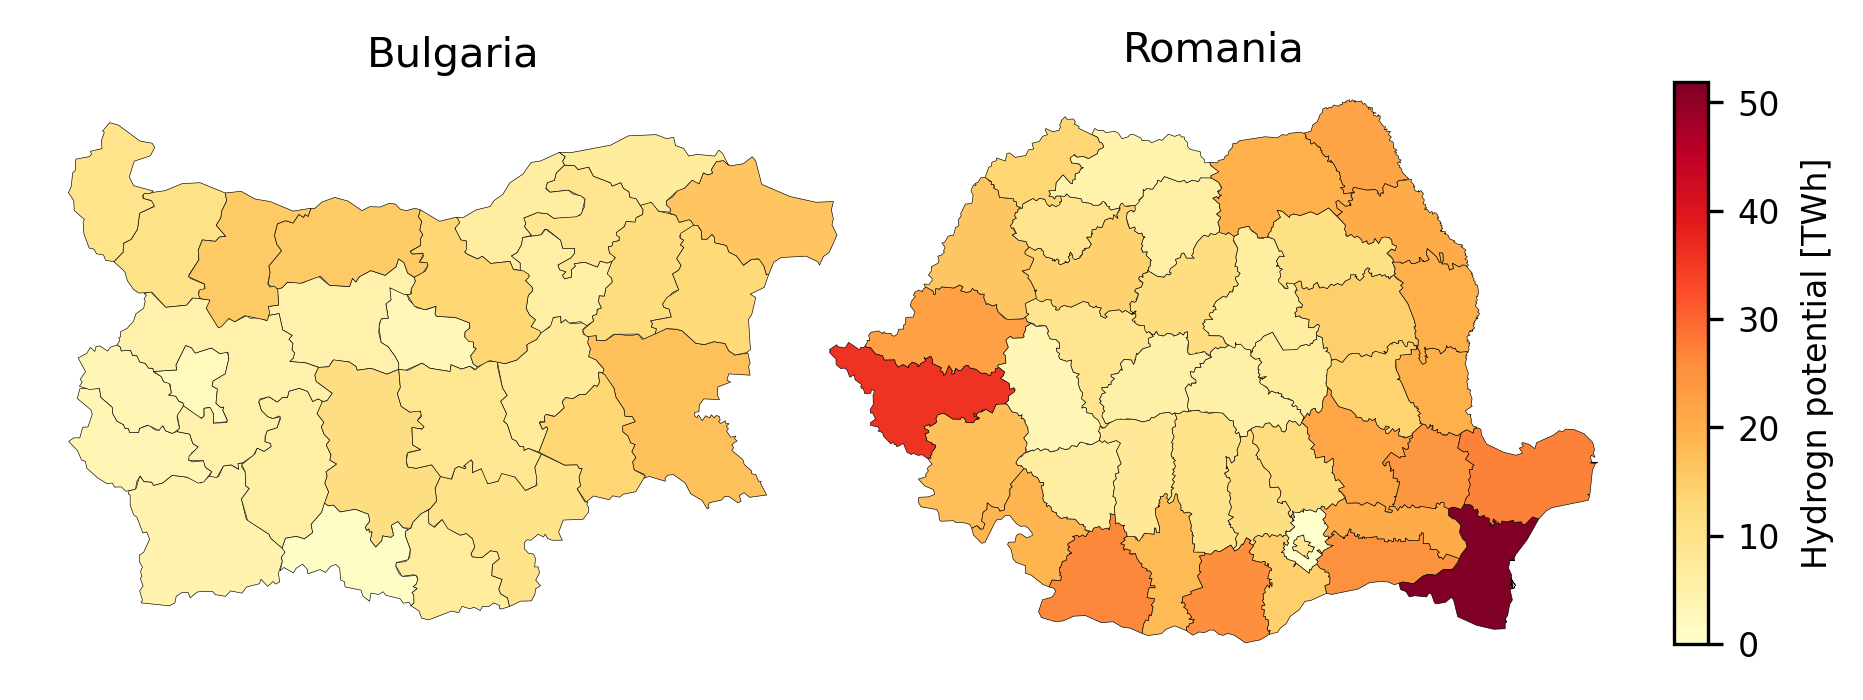

In [4]:
# =========================
# Plot regional H2 potential
# =========================
def regional_h2_potential(net):
    """
    Returns H2 potential per region.
    """

    # Find H2 export buses
    export_buses = net.buses.index[
        net.buses.index.str.contains("H2 export", case=False, na=False)
    ]

    if len(export_buses) == 0:
        raise ValueError("No H2 export bus found.")

    # Links feeding the export buses
    export_links = net.links[net.links.bus1.isin(export_buses)].copy()

    if export_links.empty:
        raise ValueError("No export links found.")

    # Hourly flow
    p1 = net.links_t.p1[export_links.index]

    # Detect sign convention automatically
    if p1.clip(lower=0).sum().sum() >= (-p1).clip(lower=0).sum().sum():
        flow = p1.clip(lower=0)
    else:
        flow = (-p1).clip(lower=0)

    # Apply snapshot weighting if available
    if hasattr(net, "snapshot_weightings"):
        weights = net.snapshot_weightings.generators.reindex(flow.index).fillna(1)
        flow = flow.mul(weights, axis=0)

    # Annual export/potential [MWh]
    export_energy = flow.sum(axis=0)

    # Region = exporting bus
    regions = export_links.bus0.str.replace(
        r"_H2.*| H2.*",
        "",
        regex=True
    )

    regional_export = export_energy.groupby(regions).sum()

    return regional_export


# =========================
# Calculate H2 potential
# =========================
export_country_1 = regional_h2_potential(country_1)
export_wo = regional_h2_potential(country_2)

# Remove "_AC"
for export in [export_country_1, export_wo]:
    export.index = (
        export.index
        .astype(str)
        .str.replace(r"_AC$", "", regex=True)
    )

# Attach to GADM
country_1_gadm = gadm_shapes_1.copy().set_index("GADM_ID")
country_2_gadm = gadm_shapes_2.copy().set_index("GADM_ID")

country_1_gadm["H2_export"] = export_country_1.reindex(country_1_gadm.index).fillna(0)
country_2_gadm["H2_export"] = export_wo.reindex(country_2_gadm.index).fillna(0)

# Common color scale
vmin = 0
vmax = max(country_1_gadm["H2_export"].max(), country_2_gadm["H2_export"].max())

print(f"Bulgaria - Sum potential: {(country_1_gadm['H2_export'].sum())/1e6:.2f} TWh")
print(f"Romania - Sum potential: {(country_2_gadm['H2_export'].sum())/1e6:.2f} TWh")


# =========================
# Plot regional H2 potential
# =========================
cm = 1 / 2.54

fig, axes = plt.subplots(
    1, 2,
    figsize=(16 * cm, 7 * cm)
)

country_1_gadm.plot(
    column="H2_export",
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.15,
    legend=False,
    vmin=vmin,
    vmax=vmax,
    ax=axes[0]
)

axes[0].set_title("Bulgaria", fontsize=10, y=0.98)
axes[0].set_axis_off()


country_2_gadm.plot(
    column="H2_export",
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.15,
    legend=False,
    vmin=vmin,
    vmax=vmax,
    ax=axes[1]
)

axes[1].set_title("Romania", fontsize=10, y=0.95)
axes[1].set_axis_off()


# Colorbar
fig.subplots_adjust(
    left=0.03,
    right=0.88,
    bottom=0.05,
    top=0.93,
    wspace=-0.1
)

sm = mpl.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)
)
sm.set_array([])

# Position colorbar:
# [left, bottom, width, height]
cbar_ax = fig.add_axes([0.90, 0.16, 0.018, 0.68])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax
)

cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.0f}")
)

cbar.ax.tick_params(labelsize=8)

cbar.set_label(
    "Hydrogn potential [TWh]",
    fontsize=8,
    labelpad=5
)

plt.show()

##### Energy Balance

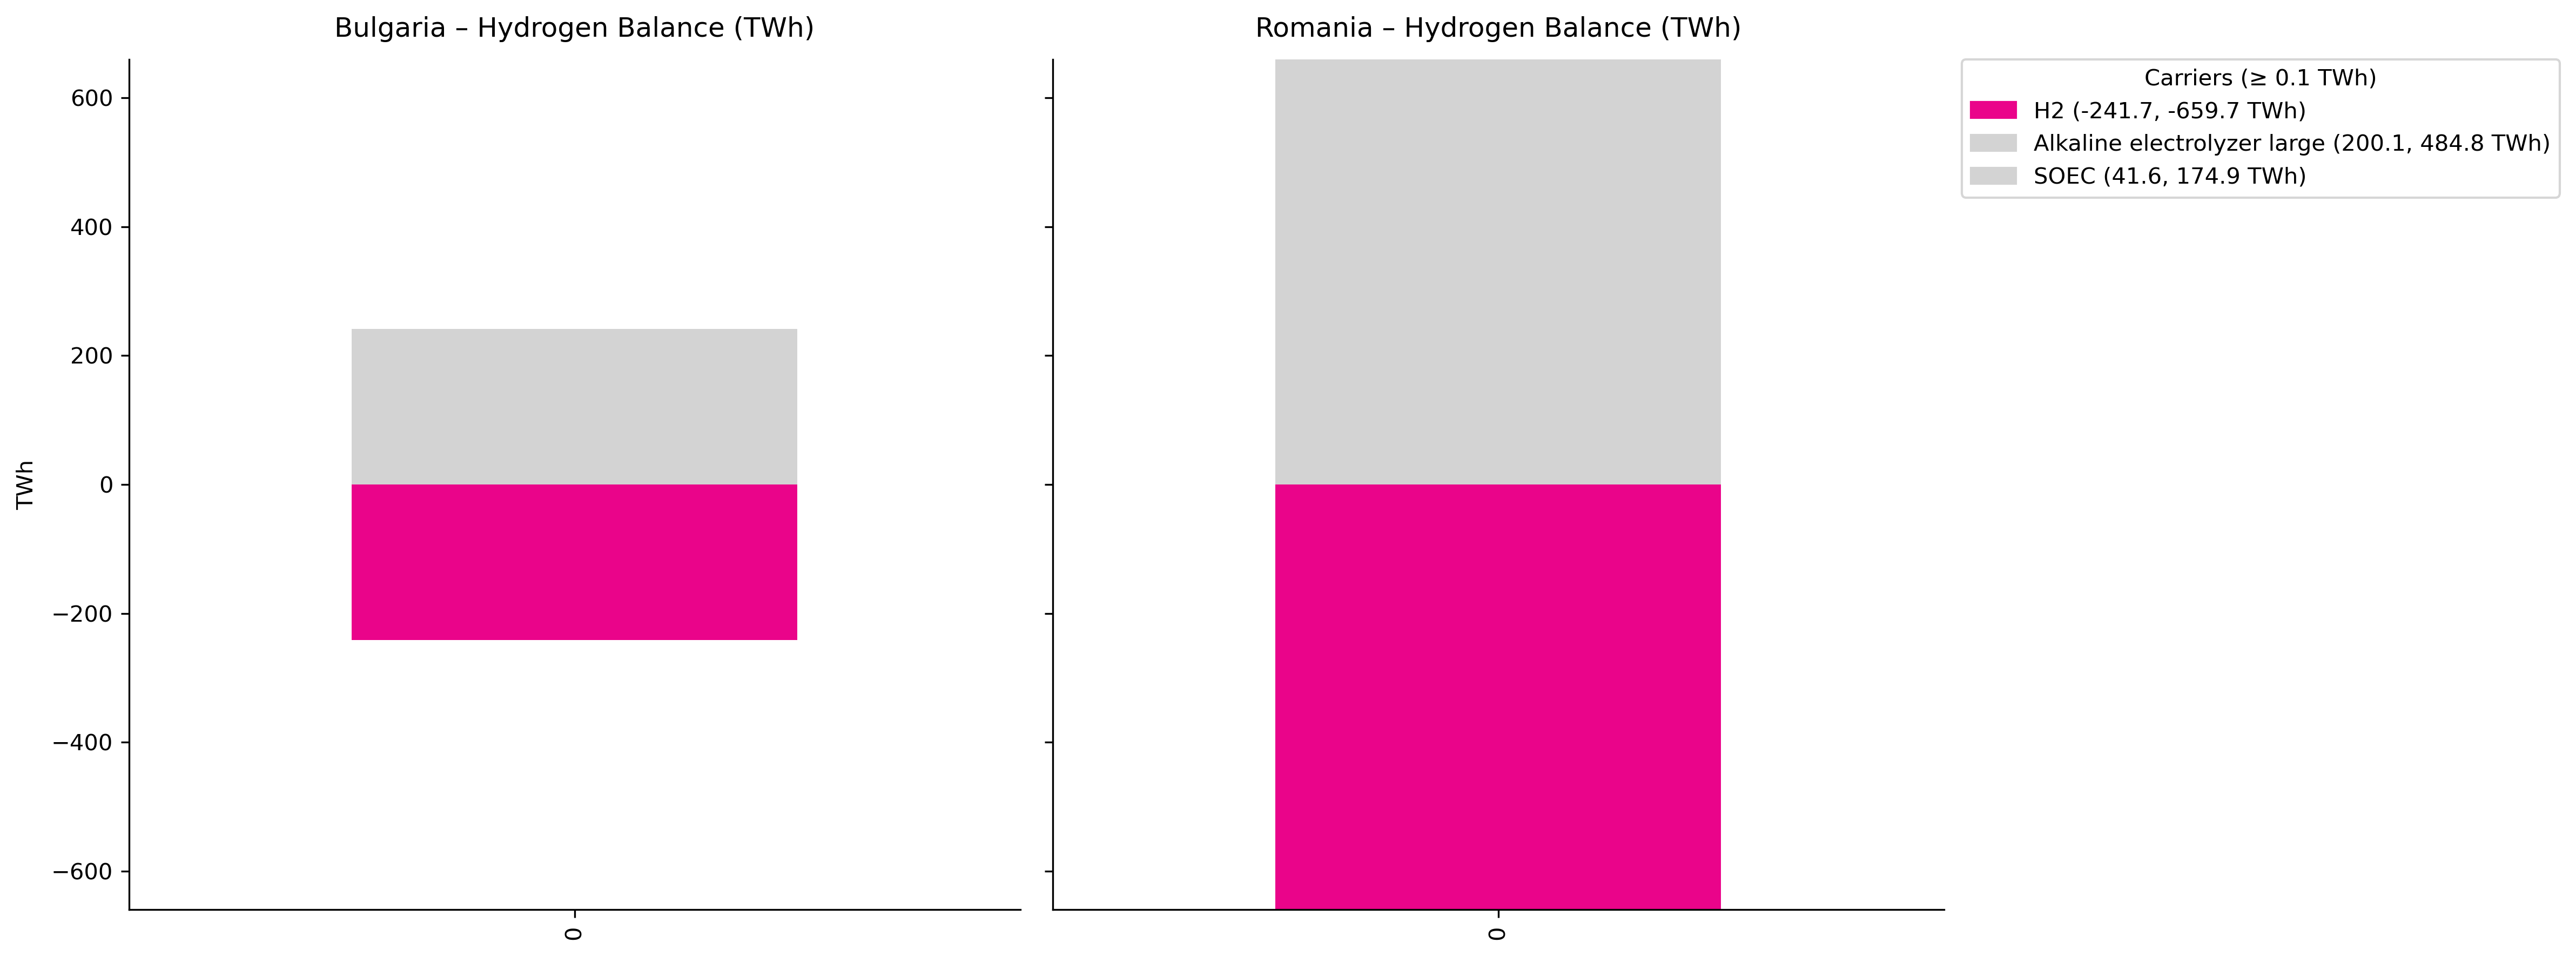

In [5]:
# =========================
# Calculate energy balance
# =========================
THRESHOLD_TWH = 0   # hide carriers with |value| < 0.1 TWh in BOTH scenarios
LEGEND_THRESHOLD_TWH = 0.1  # show only carriers >= 10 TWh in legend

def compute_energy_balance(n: pypsa.Network) -> pd.Series:
    rename_cols = {
        "-": "Load",
        "load": "load shedding",
    }

    # Aggregate energy balance by carrier and convert MWh -> TWh
    eb = (
        n.statistics.energy_balance()
        .loc[:, :, "H2"]
        .groupby("carrier")
        .sum()
        .div(1e6)  # MWh -> TWh
        .rename(index=rename_cols)
    )

    # If result is a DataFrame (multiple columns), reduce to a single number per carrier
    if isinstance(eb, pd.DataFrame):
        eb = eb.sum(axis=1)

    return eb.fillna(0.0)


# --- Compute data (as Series) ---
s_country_1 = compute_energy_balance(country_1)
s_country_2 = compute_energy_balance(country_2)

# Harmonize index (carriers) between scenarios
all_carriers = sorted(set(s_country_1.index) | set(s_country_2.index))
s_country_1 = s_country_1.reindex(all_carriers, fill_value=0.0)
s_country_2 = s_country_2.reindex(all_carriers, fill_value=0.0)

# --- Apply threshold: keep only carriers with meaningful flows in either scenario ---
mask = (s_country_1.abs() >= THRESHOLD_TWH) | (s_country_2.abs() >= THRESHOLD_TWH)
s_country_1 = s_country_1.loc[mask]
s_country_2 = s_country_2.loc[mask]

# Sort carriers by combined absolute magnitude (more stable than raw sum if signs mix)
order = (s_country_1.abs() + s_country_2.abs()).sort_values(ascending=False).index.tolist()
s_country_1 = s_country_1.reindex(order)
s_country_2 = s_country_2.reindex(order)

# Convert to 1-row DataFrames for your bar plotting style
df_country_1 = s_country_1.to_frame().T
df_country_2 = s_country_2.to_frame().T

# --- Assign colors ---
colors = [get_color(c) for c in order]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

df_country_1.plot.bar(
    stacked=True,
    ax=axes[0],
    legend=False,
    title="Bulgaria – Hydrogen Balance (TWh)",
    color=colors
)
axes[0].set_xlabel("")
axes[0].set_ylabel("TWh")

df_country_2.plot.bar(
    stacked=True,
    ax=axes[1],
    legend=False,
    title="Romania – Hydrogen Balance (TWh)",
    color=colors
)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# --- Manually build the legend (threshold-controlled) ---
labels, handles = [], []
for c, col in zip(order, colors):
    val_country_1 = float(df_country_1.iloc[0][c])
    val_country_2 = float(df_country_2.iloc[0][c])

    if (abs(val_country_1) >= LEGEND_THRESHOLD_TWH) or (abs(val_country_2) >= LEGEND_THRESHOLD_TWH):
        labels.append(f"{c} ({val_country_1:.1f}, {val_country_2:.1f} TWh)")
        handles.append(plt.Rectangle((0, 0), 1, 1, color=col))

axes[1].legend(
    handles,
    labels,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    title=f"Carriers (≥ {LEGEND_THRESHOLD_TWH} TWh)"
)

plt.tight_layout()
plt.show()


##### Hourly H2 Potential Quantity

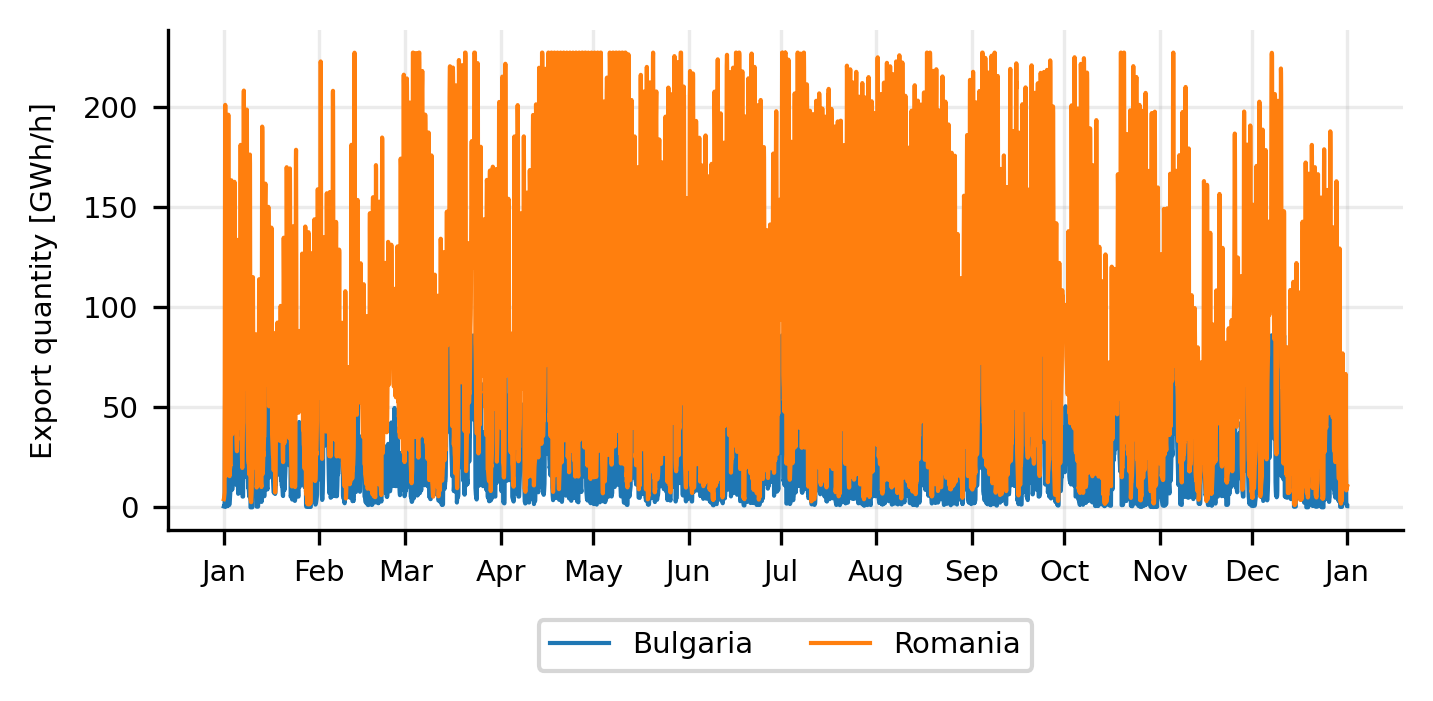

In [6]:
def h2_export_buses(net) -> pd.Index:
    names = pd.Index(net.buses.index.astype(str))
    s = names.to_series(index=net.buses.index)

    m1 = s.str.contains(r"\bh2\s*export\b", case=False, na=False)
    m2 = s.str.contains(r"\bexport\s*bus\b", case=False, na=False) & s.str.contains(r"\bh2\b", case=False, na=False)

    return net.buses.index[m1 | m2]


def hourly_h2_export_quantity(net, agg="sum") -> pd.Series:
    buses = h2_export_buses(net)
    if len(buses) == 0:
        raise ValueError("No H2 export buses found.")

    export_links = net.links[net.links.bus1.isin(buses)]
    if export_links.empty:
        raise ValueError("No links feeding the H2 export bus found.")

    p1 = net.links_t.p1[export_links.index]  # MW

    # Robust sign handling
    pos = p1.clip(lower=0).sum().sum()
    neg = (-p1).clip(lower=0).sum().sum()
    flow = p1.clip(lower=0) if pos >= neg else (-p1).clip(lower=0)

    if agg == "sum":
        s = flow.sum(axis=1)
    elif agg == "mean":
        s = flow.mean(axis=1)
    else:
        raise ValueError("agg must be 'sum' or 'mean'")

    s.name = "H2 export quantity"
    return s


def scale_energy_flow(values):
    """Return scaled values, scale factor, and unit for MWh/h-like series."""
    vmax = float(np.nanmax(values))
    if vmax >= 1e6:
        return values / 1e6, 1e6, "TWh/h"
    elif vmax >= 1e3:
        return values / 1e3, 1e3, "GWh/h"
    else:
        return values, 1.0, "MWh/h"


# ============================================================
# Build series for both scenarios and align
# ============================================================

q_country_1 = hourly_h2_export_quantity(country_1, agg="sum")
q_wo  = hourly_h2_export_quantity(country_2, agg="sum")

idx = q_country_1.index.intersection(q_wo.index)
q_country_1 = q_country_1.loc[idx]
q_wo  = q_wo.loc[idx]


# ============================================================
# Units
# ============================================================

H2_LHV_KWH_PER_KG = 33.33
KG_PER_MWH = 1000.0 / H2_LHV_KWH_PER_KG

q_country_1_s, scale, unit_left = scale_energy_flow(q_country_1.values)
q_wo_s, _, _ = scale_energy_flow(q_wo.values)

# ============================================================
# Plot
# ============================================================
cm = 1 / 2.54
fig, ax_left = plt.subplots(figsize=(13.5 * cm, 5.5 * cm))

l1, = ax_left.plot(q_country_1.index, q_country_1_s, label="Bulgaria", linewidth=1)
l2, = ax_left.plot(q_wo.index,  q_wo_s,  label="Romania", linewidth=1)

#ax_left.set_title("Hourly hydrogen potential", fontsize=9)
#ax_left.set_xlabel("Month", fontsize=7)
ax_left.set_ylabel(f"Export quantity [{unit_left}]", fontsize=7)
ax_left.grid(True, alpha=0.25)

# X-axis: every second month, no year
ax_left.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# --- Disable scientific offset text on both y-axes ---
ax_left.ticklabel_format(axis="y", style="plain", useOffset=False)
ax_left.yaxis.get_offset_text().set_visible(False)

# --- Round tick labels (no offsets, no noise) ---
ax_left.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}"))

# Legend below plot
ax_left.legend(
    handles=[l1, l2],
    labels=["Bulgaria", "Romania"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True,
    fontsize=7
)

ax_left.tick_params(axis="both", labelsize=7)

plt.show()

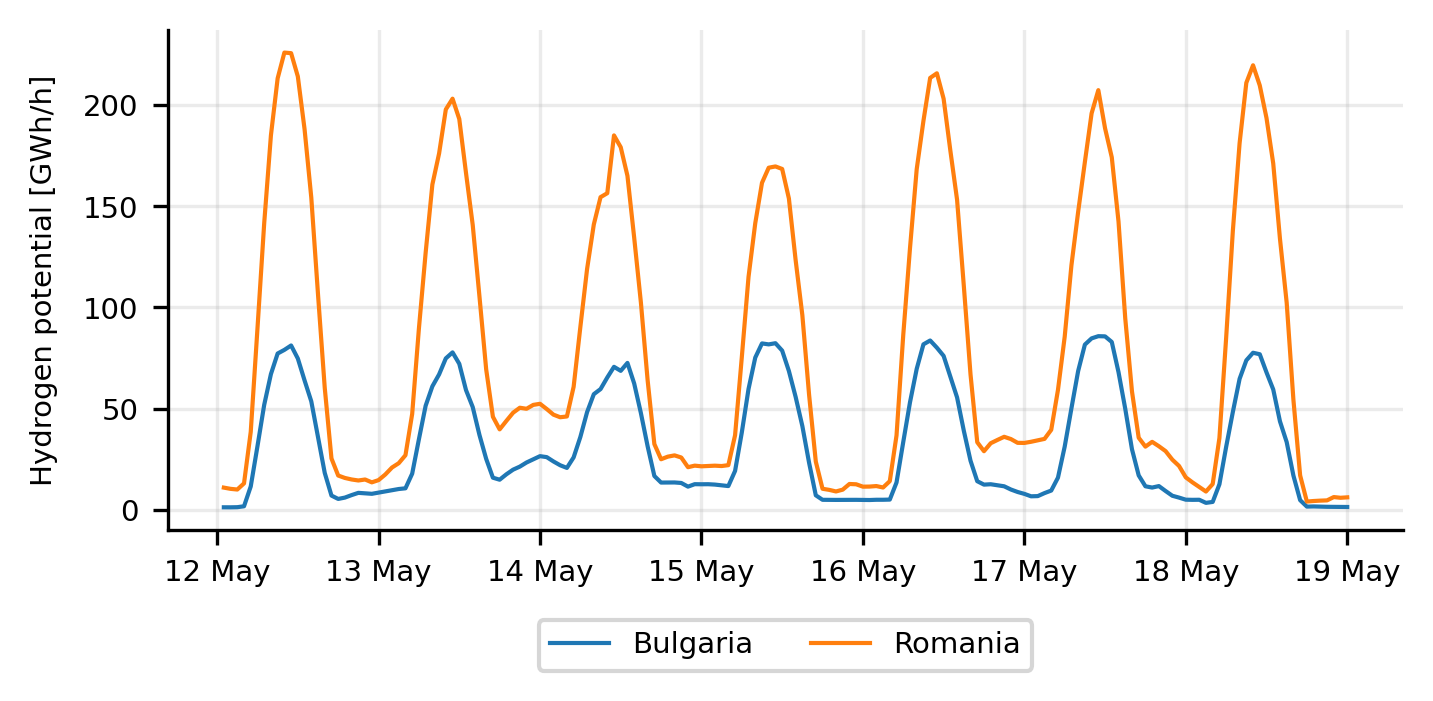

In [7]:
# ============================================================
# Select hourly plotting period
# ============================================================

start = "2013-05-12 01:00:00"
end   = "2013-05-19 00:00:00"

q_country_1_range = q_country_1.loc[start:end]
q_wo_range  = q_wo.loc[start:end]

if q_country_1_range.empty or q_wo.empty:
    raise ValueError(
        f"No data available between {start} and {end}. "
        f"Available period: {idx.min()} to {idx.max()}"
    )

q_country_1_s_range, scale, unit_left = scale_energy_flow(q_country_1_range.values)
q_wo_s_range, _, _ = scale_energy_flow(q_wo_range.values)

# ============================================================
# Plot
# ============================================================
cm = 1 / 2.54
fig, ax_left = plt.subplots(figsize=(13.5 * cm, 5.5 * cm))

l1, = ax_left.plot(q_country_1_range.index, q_country_1_s_range, label="Bulgaria", linewidth=1)
l2, = ax_left.plot(q_wo_range.index,  q_wo_s_range,  label="Romania", linewidth=1)

#ax_left.set_title("Hourly hydrogen potential", fontsize=9)
#ax_left.set_xlabel("Month", fontsize=7)
ax_left.set_ylabel(f"Hydrogen potential [{unit_left}]", fontsize=7)
ax_left.grid(True, alpha=0.25)

# X-axis: every second month, no year
ax_left.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# --- Disable scientific offset text on both y-axes ---
ax_left.ticklabel_format(axis="y", style="plain", useOffset=False)
ax_left.yaxis.get_offset_text().set_visible(False)

# --- Round tick labels (no offsets, no noise) ---
ax_left.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}"))

# Legend below plot
ax_left.legend(
    handles=[l1, l2],
    labels=["Bulgaria", "Romania"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True,
    fontsize=7
)

ax_left.tick_params(axis="both", labelsize=7)

plt.show()

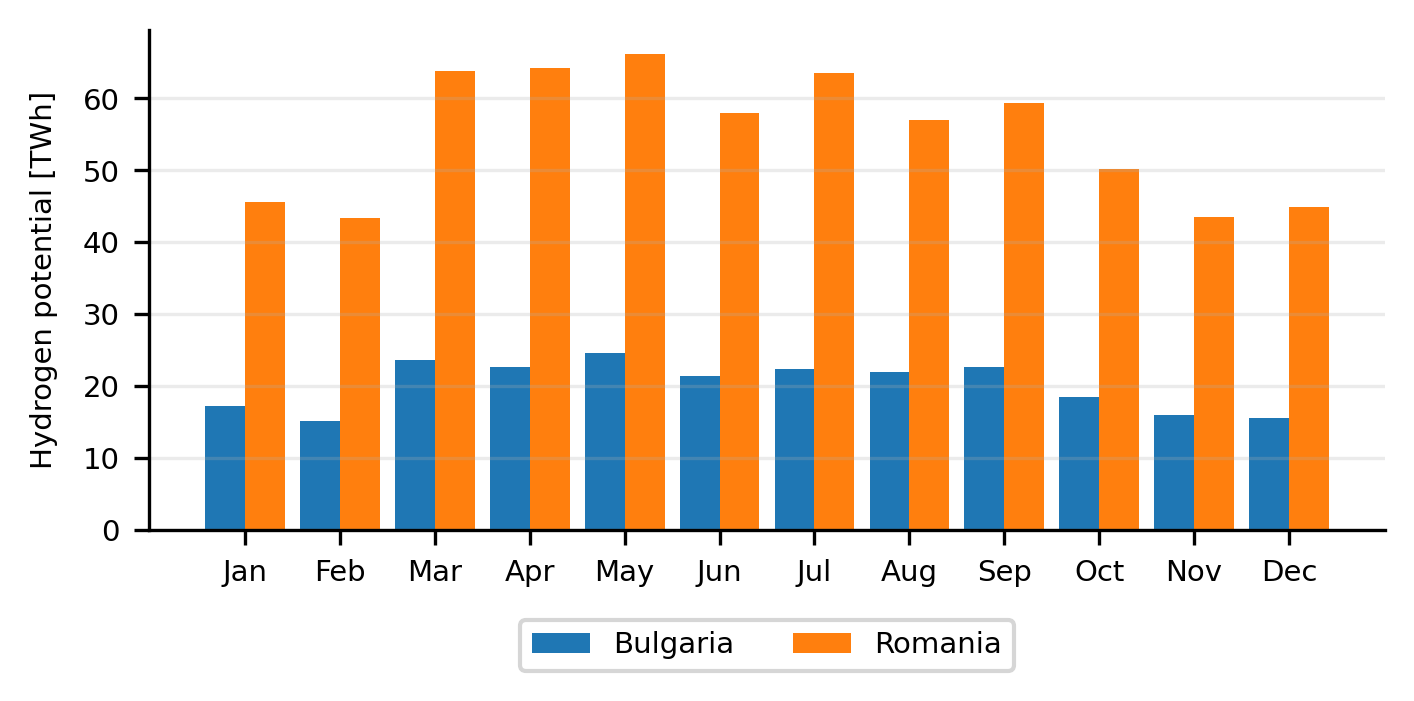

In [8]:
# aggregate export quantitys to monthly sums and plot them for country_1 and country_2 next to each other
def h2_export_buses(net) -> pd.Index:
    names = pd.Index(net.buses.index.astype(str))
    s = names.to_series(index=net.buses.index)
    m1 = s.str.contains(r"\bh2\s*export\b", case=False, na=False)
    m2 = s.str.contains(r"\bexport\s*bus\b", case=False, na=False) & s.str.contains(r"\bh2\b", case=False, na=False)
    return net.buses.index[m1 | m2]


def hourly_h2_export_quantity(net, agg="sum") -> pd.Series:
    """
    Hourly H2 export quantity time series [MWh/h] (i.e., MW).
    Uses all links that feed into the H2 export bus (bus1 in export buses).
    """
    buses = h2_export_buses(net)
    if len(buses) == 0:
        raise ValueError("No H2 export buses found. Adjust heuristic in h2_export_buses().")

    links = net.links.copy()
    export_links = links[links.bus1.isin(buses)]
    if export_links.empty:
        raise ValueError("No links feeding the H2 export bus found.")

    p1 = net.links_t.p1[export_links.index]  # MW

    # Robust sign handling
    pos = p1.clip(lower=0).sum().sum()
    neg = (-p1).clip(lower=0).sum().sum()
    flow = p1.clip(lower=0) if pos >= neg else (-p1).clip(lower=0)

    s = flow.sum(axis=1) if agg == "sum" else flow.mean(axis=1)
    s.name = "H2 export quantity [MWh/h]"
    return s


# ============================================================
# Snapshot weights -> hours per snapshot (needed for correct monthly MWh)
# ============================================================

def snapshot_hours(net) -> pd.Series:
    """
    Returns hours per snapshot as a Series indexed by net.snapshots.
    Uses net.snapshot_weightings['generators'] if present, else 1 hour per snapshot.
    """
    if hasattr(net, "snapshot_weightings") and net.snapshot_weightings is not None:
        try:
            if "generators" in net.snapshot_weightings:
                w = net.snapshot_weightings["generators"].copy()
                # In PyPSA-Earth this is typically hours; keep as-is.
                return w.reindex(net.snapshots)
        except Exception:
            pass
    return pd.Series(1.0, index=net.snapshots)


# ============================================================
# Monthly aggregation: sum_t (MW * hours) => MWh per month
# ============================================================

def monthly_export_mwh(net) -> pd.Series:
    q = hourly_h2_export_quantity(net, agg="sum")         # MW
    h = snapshot_hours(net).reindex(q.index).fillna(0.0)  # hours
    e = q * h                                             # MWh per snapshot

    # Ensure DateTimeIndex for resample
    if not isinstance(e.index, pd.DatetimeIndex):
        e.index = pd.to_datetime(e.index)

    m = e.resample("MS").sum()  # Month Start frequency
    m.name = "Monthly H2 export [MWh]"
    return m


# ============================================================
# Compute monthly sums for both scenarios
# ============================================================

m_country_1 = monthly_export_mwh(country_1)
m_wo  = monthly_export_mwh(country_2)

# Align months
months = m_country_1.index.union(m_wo.index)
m_country_1 = m_country_1.reindex(months).fillna(0.0)
m_wo  = m_wo.reindex(months).fillna(0.0)

# Convert to TWh for nicer axis
t_country_1 = m_country_1 / 1e6
t_wo  = m_wo  / 1e6


# ============================================================
# Plot: side-by-side bars per month (country_1 vs country_2)
# ============================================================

cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(13.5 * cm, 5.5 * cm))


x = np.arange(len(months))
width = 0.42

ax.bar(x - width/2, t_country_1.values, width=width, label="Bulgaria")
ax.bar(x + width/2, t_wo.values,  width=width, label="Romania")

#ax.set_title("Monthly hydrogen potential", fontsize=9)
ax.set_ylabel("Hydrogen potential [TWh]", fontsize=7)
#ax.set_xlabel("Month")
ax.grid(True, axis="y", alpha=0.25)

ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%b") for d in months], rotation=0)

# Legend below the plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True,
    fontsize=7
)

ax.tick_params(axis="both", labelsize=7)

plt.show()